# Práctica: Clustering con K-Means (EEG Dataset)

Aplicación de K-Means con distintos valores de k y visualización en 3D usando PCA.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from mpl_toolkits.mplot3d import Axes3D

In [2]:
# Cargar dataset (asegúrate que el archivo esté en la misma carpeta)
data = pd.read_csv("EEG Eye State.arff", comment='@', header=None)

X = data.iloc[:, :-1].values
y = data.iloc[:, -1].values

print("Shape:", X.shape)

Shape: (14980, 14)


In [3]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [4]:
ks = [3, 5, 7, 9]
models = {}

for k in ks:
    kmeans = KMeans(n_clusters=k, random_state=42)
    y_pred = kmeans.fit_predict(X_scaled)
    models[k] = (kmeans, y_pred)

In [5]:
pca = PCA(n_components=3)
X_pca = pca.fit_transform(X_scaled)

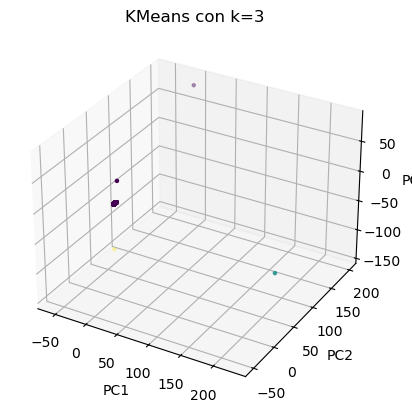

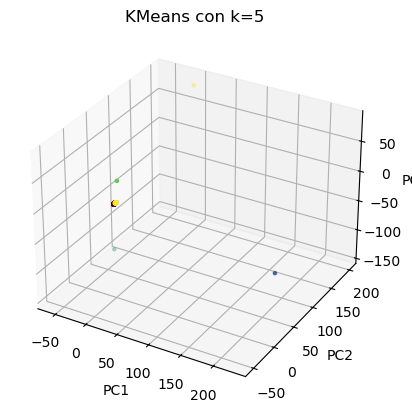

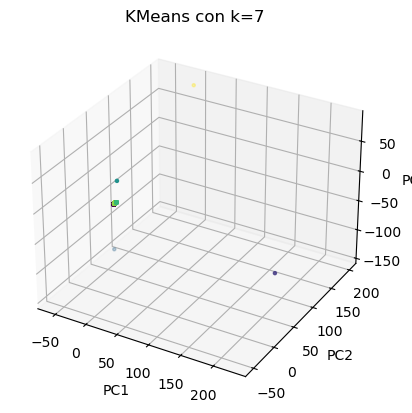

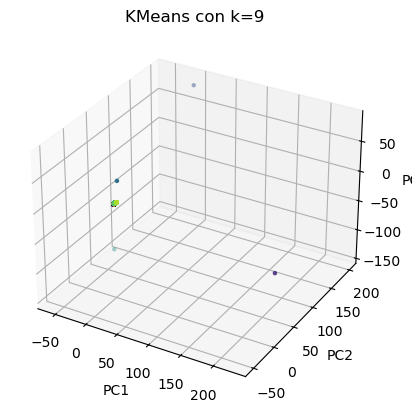

In [6]:
for k in ks:
    kmeans, y_pred = models[k]

    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')

    ax.scatter(X_pca[:, 0], X_pca[:, 1], X_pca[:, 2],
               c=y_pred, s=5, cmap='viridis')

    ax.set_title(f"KMeans con k={k}")
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    ax.set_zlabel("PC3")

    plt.show()

## Análisis de Resultados

- **k=3**: Clusters generales, posible mezcla de patrones.
- **k=5**: Mejor separación, equilibrio entre detalle y simplicidad.
- **k=7**: Mayor detalle, subdivisión de grupos.
- **k=9**: Alta fragmentación, posible sobreajuste.

### Conclusión
KMeans permite identificar patrones en los datos EEG. Valores intermedios como k=5 o k=7 suelen ser más adecuados.
